## End-to-end tutorial: REINVENT → Maize → GOLD → scores back to REINVENT

This notebook demonstrates the **closed loop** that many practical design workflows need:

1. **REINVENT4** generates a batch of candidate molecules as **SMILES**.
2. **Maize** routes that batch through a graph of nodes.
3. **SMILES → molecules** conversion (so docking tools can consume 3D-ready structures).
4. **GOLD docking** evaluates each molecule against a prepared receptor and binding site.
5. **Score conversion** normalizes docking scores into the numeric range REINVENT expects.
6. The converted scores are **fed back** into REINVENT so the next epoch proposes better molecules.

### What Maize is doing here

Maize acts as the **orchestrator**: each node runs as its own process and communicates via ports/channels. This makes it straightforward to plug a generative model, chemistry conversion, and docking into one repeatable workflow.

### Prerequisites

- Tutorials 1–4 completed.
- A valid **CCDC license**.
- A REINVENT **prior** in `priors/`.
- Prepared protein + reference ligand in `data/` (e.g. `protein_prepared.mol2` and `4lqm_ligand.mol2` from Tutorial 3).
- A `config.toml` in the repo root (copy `config.toml.example` → `config.toml` and fill in tool paths).

### Important


In [1]:
import workshop_setup
from pathlib import Path
import os


Workshop environment variables successfully configured!


In [2]:
from maize.core.workflow import Workflow
from pathlib import Path
from maize.steps.mai.molecule import Smiles2Molecules
from maize.steps.mai.misc import ReInvent
from nodes import GOLDDocking, SaveIsomers, ScoreConverter

/nfs/home/myuecel3/miniforge3/envs/frontiers_medchem/lib/python3.10/site-packages/ccdc/__init__.py:237: UserWarning: 
Could not find the CSD database in the CSD Software installation.  Data dependent features will not be available.

For further help with installing and configuring data please visit
the support page at https://www.ccdc.cam.ac.uk/csds_install_help

  warnings.warn(CSD_DATABASE_NOT_FOUND_MSG)


In [3]:
### THE PATHS IN THIS NOTEBOOK ARE EXAMPLES. PLEASE CHANGE THEM TO YOUR OWN PATHS ###

flow = Workflow(name='reinvent_dock')
flow.config.update(Path('/nfs/home/myuecel3/Frontiers_MedChem/config.toml'))

rnve = flow.add(ReInvent)
smi2mol = flow.add(Smiles2Molecules, loop=True)
gold = flow.add(GOLDDocking, loop=True)
converter = flow.add(ScoreConverter, loop=True)

# Set parameters
gold.output_base_dir.set(Path('/nfs/home/myuecel3/Frontiers_MedChem/data/output'))
gold.protein_file.set(Path('/nfs/home/myuecel3/Frontiers_MedChem/data/protein_prepared.mol2'))
gold.ref_ligand.set(Path('/nfs/home/myuecel3/Frontiers_MedChem/data/4lqm_ligand.mol2'))
# You can also choose 'from_ligand'
gold.binding_site_mode.set('from_residues')
gold.binding_site_residues.set('A:VAL717')

# Connect the nodes
flow.connect(rnve.out, smi2mol.inp)
flow.connect(smi2mol.out, gold.inp)
flow.connect(gold.out, converter.inp)
flow.connect(converter.out, rnve.inp) 

# REINVENT configuration
rnve_conf = Path('/nfs/home/myuecel3/Frontiers_MedChem/configs/reinvent.toml')
rnve.configuration.set(rnve_conf)

rnve.max_epoch.set(20)  
rnve.low.set(0.0)
rnve.high.set(5)
rnve.reverse.set(False)
rnve.batch_size.set(32) # Number of molecules to generate each epoch
# GOLD configuration
gold.ndocking.set(10)
gold.scoring_function.set('plp')



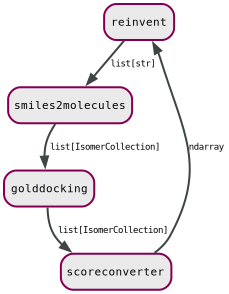

In [ ]:
# Check and visualize the workflow
flow.check()
dot =flow.visualize()
dot.render('workflow_visualization', format='pdf') # This will save the visualization as a PDF file named 'workflow_visualization.pdf'
dot


In [ ]:
# Execute the workflow
flow.execute()